# From Chains to Graphs: Agentic RAG With LangGraph

## From Chains to Graphs: Agentic RAG With LangGraph

### 1. Motivation: Why Move Beyond Chains?

Traditional RAG pipelines in frameworks like LangChain are often built as **linear chains**:

* Retrieve → Process → Generate → Return

This works well for simple tasks, but breaks down when you need:

* Iteration (retry retrieval, refine queries)
* Conditional logic (different paths depending on results)
* Multi-step reasoning
* Tool use and orchestration

**Key limitation:** Chains are **static and sequential**, while real-world reasoning is **dynamic and stateful**.

---

### 2. Enter Graph-Based Architectures

LangGraph introduces a **graph-based execution model**, where:

* Nodes = computation steps (LLMs, tools, retrievers)
* Edges = transitions (deterministic or conditional)
* State = shared memory across the workflow

This enables:

* Cycles (loops)
* Branching (if/else decisions)
* Stateful execution
* Multi-agent coordination

---

### 3. Core Concept: Agentic RAG

**Agentic RAG** combines:

* Retrieval-Augmented Generation (RAG)
* Agent-like reasoning and decision-making

Instead of a fixed pipeline, the system behaves like an **agent** that can:

1. Decide when to retrieve
2. Evaluate retrieved information
3. Refine queries if needed
4. Choose tools dynamically
5. Iterate until a stopping condition is met

---

### 4. Architecture Comparison

#### Traditional RAG (Chain)

```
User Query
   ↓
Retriever
   ↓
LLM (Generate Answer)
   ↓
Output
```

* Single pass
* No feedback loop
* No reasoning about retrieval quality

---

#### Agentic RAG (Graph)

```
        ┌──────────────┐
        │   Retrieve   │
        └──────┬───────┘
               ↓
        ┌──────────────┐
        │  Evaluate    │◄──────────┐
        └──────┬───────┘           │
               ↓                   │
        ┌──────────────┐           │
        │   Generate   │           │
        └──────┬───────┘           │
               ↓                   │
            Output                │
                                 │
        (If not good → refine query)
```

* Iterative
* Self-correcting
* Conditional routing

---

### 5. Key Components in LangGraph

#### 5.1 State

A shared dictionary-like object:

```python
state = {
    "question": "...",
    "documents": [...],
    "answer": "...",
    "flag": "approve"  # or "retry"
}
```

* Passed between nodes
* Updated at each step

---

#### 5.2 Nodes

Each node is a function:

```python
def retrieve_node(state):
    docs = retriever.invoke(state["question"])
    return {**state, "documents": docs}
```

Examples:

* Retrieval node
* LLM reasoning node
* Evaluation node
* Tool execution node

---

#### 5.3 Edges

Edges define transitions:

* **Linear edge:** A → B
* **Conditional edge:** depends on state

```python
workflow.add_conditional_edges(
    "evaluate_node",
    lambda state: state["flag"],
    {
        "approve": "generate_node",
        "retry": "rewrite_query_node"
    }
)
```

---

#### 5.4 Cycles (Loops)

A defining feature:

* Retry retrieval if results are poor
* Re-run reasoning with updated context

This is **not possible in simple chains**.

---

### 6. Example: Agentic RAG Flow

1. User asks a question
2. Retrieve documents
3. LLM evaluates relevance
4. If low quality → rewrite query
5. Retrieve again
6. Generate answer
7. Final validation

---

### 7. Benefits of Graph-Based Agentic RAG

#### Flexibility

* Dynamic execution paths
* Easily extendable

#### Robustness

* Self-correction loops
* Error handling

#### Interpretability

* Explicit structure (graph visualization)

#### Composability

* Combine multiple agents/tools

---

### 8. Relation to Agentic AI Concepts

This approach aligns with:

* **ReAct prompting** (reason + act loops)
* **Tool-using agents**
* **Planning + execution separation**
* **Multi-step reasoning systems**

LangGraph essentially provides the **runtime for agent orchestration**.

---

### 9. When to Use Agentic RAG

Use it when:

* Retrieval quality is inconsistent
* You need iterative refinement
* Tasks require decision-making
* Multiple tools or data sources are involved

Avoid it when:

* Simple Q&A suffices
* Latency must be minimal
* Pipeline is strictly linear

---

### 10. Mental Model Shift

* **Chains → Pipelines**
* **Graphs → Systems**

You are no longer:

> "Calling an LLM once"

You are:

> "Designing a reasoning system with memory, control flow, and feedback loops"

---

### 11. Minimal LangGraph Pattern

```python
from langgraph.graph import StateGraph, END

workflow = StateGraph(dict)

workflow.add_node("retrieve", retrieve_node)
workflow.add_node("evaluate", evaluate_node)
workflow.add_node("generate", generate_node)

workflow.set_entry_point("retrieve")

workflow.add_edge("retrieve", "evaluate")

workflow.add_conditional_edges(
    "evaluate",
    lambda state: state["flag"],
    {
        "approve": "generate",
        "retry": "retrieve",
        "END": END
    },
)

app = workflow.compile()
```

---

### 12. Key Takeaway

**Agentic RAG with LangGraph transforms RAG from a static pipeline into a dynamic, self-improving system by introducing:**

* State
* Control flow
* Iteration
* Decision-making

This is a foundational pattern for building **production-grade AI agents**.


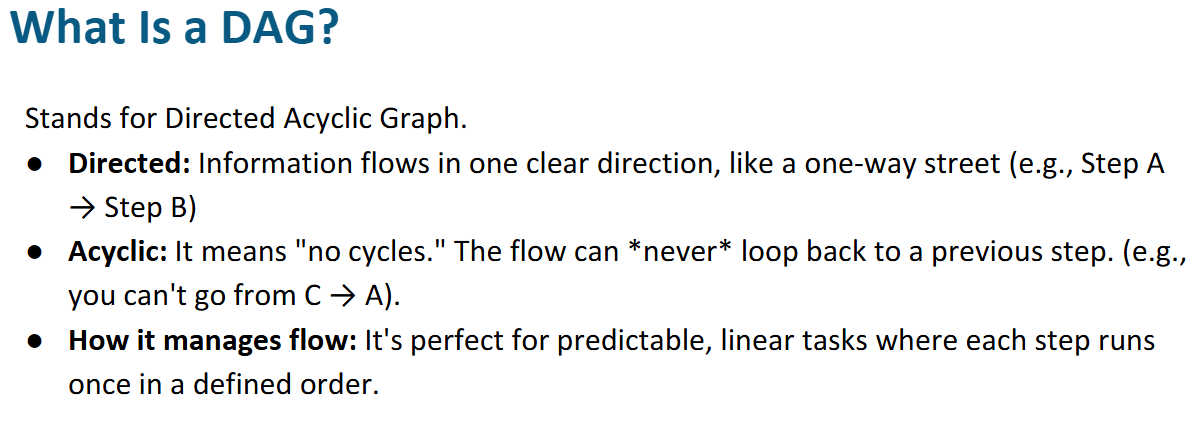

## What Is a DAG?

A **Directed Acyclic Graph (DAG)** is a foundational data structure used to model workflows, dependencies, and execution pipelines in systems such as data engineering pipelines, task schedulers, and modern AI orchestration frameworks.

---

### Formal Definition

A DAG is a graph $G = (V, E)$ where:

- $V$ = set of vertices (nodes)
- $E$ = set of directed edges (connections between nodes)

Subject to the constraint:

$$
\text{There are no cycles in } G
$$

This means there is **no path** such that:

$$
v_1 \rightarrow v_2 \rightarrow \dots \rightarrow v_n \rightarrow v_1
$$

---

### Directed

- Each edge has a **clear direction**, representing flow or dependency.
- If there is an edge $A \rightarrow B$, then:
  - $A$ must be completed **before** $B$
  - Information flows **from $A$ to $B$**

**Key Insight:**
- Direction encodes **causality** and **execution order**

**Example:**
- Data pipeline: Extract → Transform → Load
- Task dependency: Step A → Step B → Step C

---

### Acyclic

- "Acyclic" means **no loops or cycles are allowed**
- You cannot return to a previously visited node

**Invalid (Cycle):**
- $A \rightarrow B \rightarrow C \rightarrow A$

**Valid (DAG):**
- $A \rightarrow B \rightarrow C$

**Why this matters:**
- Prevents infinite loops
- Ensures tasks can be executed in a **finite and deterministic order**

---

### Execution Model

DAGs enable **topological ordering**, which defines a valid sequence of execution:

$$
\text{If } (u \rightarrow v) \in E, \text{ then } u \text{ comes before } v
$$

This allows systems to:

- Determine execution order automatically
- Parallelize independent nodes
- Guarantee all dependencies are satisfied before execution

---

### How DAGs Manage Flow

DAGs are ideal for **predictable, structured workflows**:

- Each node runs **once**
- Execution follows a **predefined dependency structure**
- No dynamic loops or runtime re-routing

**Characteristics:**
- Deterministic
- Transparent execution path
- Easy to debug and visualize

---

### Example DAG Workflow

```text
        A
       / \
      B   C
       \ /
        D
````

**Execution Order (valid topological sorts):**

* A → B → C → D
* A → C → B → D

**Observations:**

* $B$ and $C$ can run in parallel after $A$
* $D$ depends on both $B$ and $C$

---

### DAGs in AI and Data Systems

DAGs are widely used in:

* Data pipelines (e.g., ETL workflows)
* Task schedulers (e.g., Airflow)
* ML pipelines (feature engineering → training → evaluation)
* Traditional RAG pipelines (Retrieve → Generate)

---

### Limitations of DAGs

While powerful, DAGs have important constraints:

* No support for **loops or iteration**
* No dynamic decision-making at runtime
* Limited adaptability for complex reasoning tasks

This makes DAGs less suitable for:

* Agentic systems
* Iterative refinement processes
* Feedback-driven workflows

---

### Key Takeaways

* DAG = Directed + Acyclic structure for modeling dependencies
* Guarantees **ordered, one-pass execution**
* Enables **parallelism** where dependencies allow
* Forms the backbone of many traditional pipeline systems


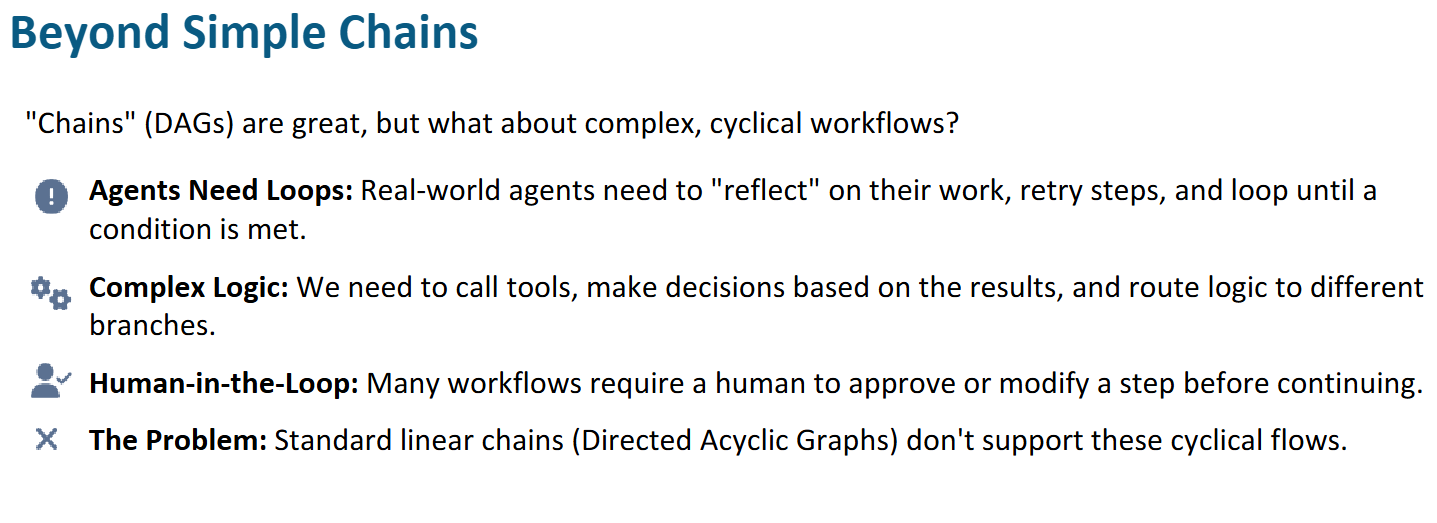

## Beyond Simple Chains

While **Directed Acyclic Graphs (DAGs)** are powerful for structuring workflows, they fall short when modeling **real-world intelligent systems**, which often require iteration, adaptation, and dynamic decision-making.

---

### The Limitation of Chains

Traditional "chains" (i.e., DAG-based workflows) assume:

- A fixed sequence of steps
- One-pass execution
- No revisiting of previous states

Formally, DAGs enforce:

$$
\forall v \in V, \; \text{there is no path such that } v \rightarrow \dots \rightarrow v
$$

This constraint prevents **cycles**, which are essential for more advanced behaviors.

---

### Agents Need Loops

Real-world intelligent agents operate iteratively:

- Reflect on outputs
- Detect errors or low-quality results
- Retry or refine actions
- Continue until a goal or condition is satisfied

This introduces **cyclical behavior**, which can be expressed as:

$$
\text{state}_{t+1} = f(\text{state}_t)
$$

Where the system repeatedly updates its state until:

$$
\text{termination condition} = \text{True}
$$

**Key Insight:**
- Intelligence often emerges from **iteration + feedback**, not single-pass execution

---

### Complex Logic and Decision-Making

Modern workflows require:

- Tool invocation (APIs, databases, external systems)
- Conditional branching based on intermediate results
- Dynamic routing between different processing paths

This can be represented as:

$$
\text{next\_node} =
\begin{cases}
A & \text{if condition}_1 \\
B & \text{if condition}_2 \\
C & \text{otherwise}
\end{cases}
$$

**Implications:**
- Execution is no longer predetermined
- The system must **decide what to do next at runtime**

---

### Human-in-the-Loop (HITL)

Many production systems require human oversight:

- Approval before executing critical actions
- Manual correction of intermediate outputs
- Escalation when confidence is low

This introduces **external interrupts** into the workflow:

$$
\text{continue} =
\begin{cases}
\text{True} & \text{if human approves} \\
\text{False} & \text{otherwise}
\end{cases}
$$

**Result:**
- Workflow becomes **interactive**, not purely automated

---

### The Core Problem

DAG-based chains cannot represent:

- Cycles (no looping or retries)
- Dynamic control flow
- Runtime decision-making
- Interrupt-driven execution (e.g., human approval)

This limitation can be summarized as:

$$
\text{DAG} \Rightarrow \text{single-pass, static execution}
$$

---

### Why This Matters

As systems evolve toward **Agentic AI**, we need:

- Iterative reasoning
- Feedback loops
- Adaptive execution paths
- Integration of tools and humans

These requirements fundamentally **break the DAG model**.

---

### Transition to Graph-Based Thinking

To support these capabilities, workflows must evolve from:

- **Chains (DAGs)** → Fixed, linear, acyclic

To:

- **Graphs with cycles** → Dynamic, iterative, stateful

This shift enables:

- Reflection loops
- Retry mechanisms
- Conditional routing
- Continuous improvement within a single execution

---

### Key Takeaways

- DAGs are insufficient for modeling intelligent, adaptive systems
- Real-world agents require **loops, decisions, and interaction**
- Cyclical workflows enable **iteration and refinement**
- Moving beyond chains is essential for building **agentic systems**



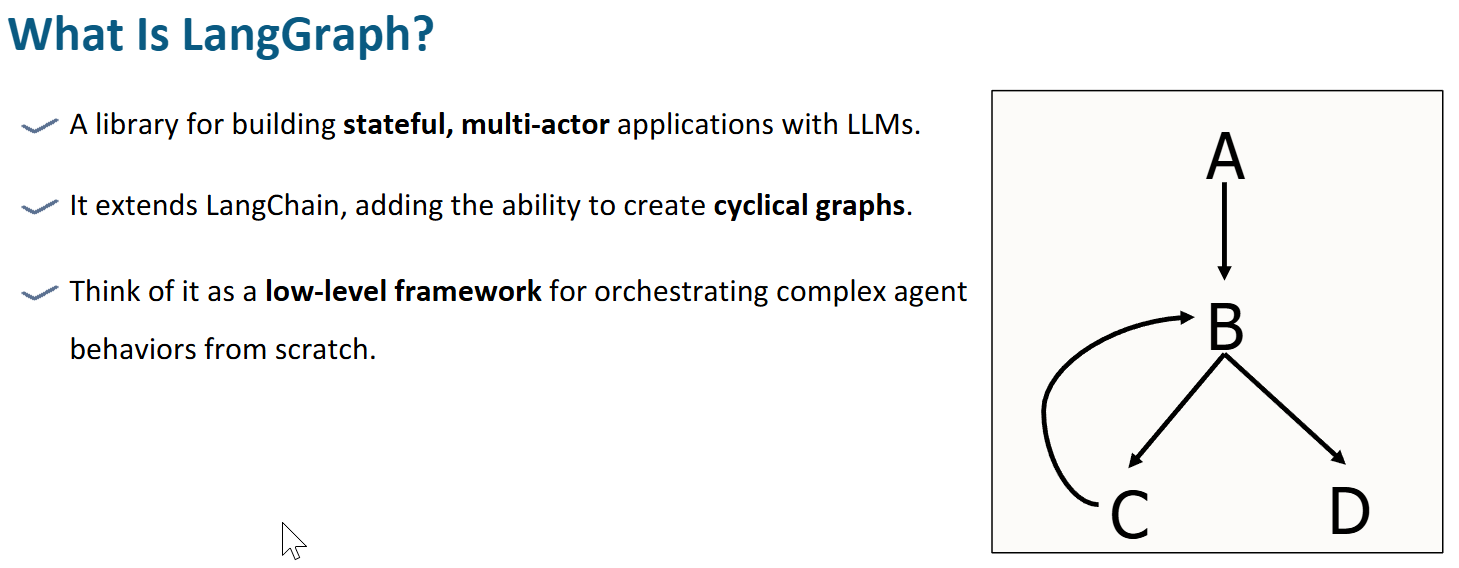

## What Is LangGraph?

**LangGraph** is a framework designed to build **stateful, multi-actor applications** powered by Large Language Models (LLMs), enabling complex, dynamic, and iterative workflows that go beyond traditional linear pipelines.

---

### Core Definition

LangGraph can be understood as a system for defining a graph:

$$
G = (V, E, S)
$$

Where:

- $V$ = nodes (functions, LLM calls, tools, agents)
- $E$ = edges (transitions between nodes)
- $S$ = shared state (data passed and updated across the graph)

Unlike DAGs, LangGraph allows:

$$
\text{cycles in } G
$$

This enables **looping, retrying, and iterative reasoning**.

---

### Stateful Execution

A key feature of LangGraph is **statefulness**:

- A shared state object is passed between nodes
- Each node can **read and update** the state

Example:

```python
state = {
    "question": "...",
    "documents": [...],
    "answer": "...",
    "status": "retry"
}
````

Formally, each node behaves like:

$$
\text{state}_{t+1} = f(\text{state}_t)
$$

This allows the system to evolve over time rather than executing once.

---

### Multi-Actor Systems

LangGraph supports **multiple interacting components (actors)**:

* LLMs (reasoning, generation)
* Tools (APIs, databases, search)
* Evaluators (validation, scoring)
* Humans (approval, intervention)

Each actor is represented as a node, enabling:

* Collaboration between components
* Separation of responsibilities
* Modular system design

---

### Cyclical Graphs

Unlike DAGs, LangGraph supports **cycles**, enabling:

* Retry loops
* Reflection steps
* Iterative refinement

Example flow:

```text
A → B → C
     ↑   ↓
     └───┘
```

This loop allows the system to:

* Re-evaluate outputs
* Improve results
* Continue until a condition is met

---

### Conditional Routing

LangGraph enables dynamic control flow:

$$
\text{next_node} =
\begin{cases}
A & \text{if condition}_1 \
B & \text{if condition}_2 \
C & \text{otherwise}
\end{cases}
$$

This means:

* Execution is **not fixed מראש**
* The system decides the next step **at runtime**

---

### Low-Level Orchestration Framework

LangGraph is considered **low-level** because:

* You explicitly define nodes, edges, and state
* You control execution logic in detail
* You design the agent behavior from first principles

This contrasts with higher-level abstractions that hide orchestration complexity.

---

### Relationship with LangChain

LangGraph **extends** $\text{LangChain}$ by:

* Adding support for cycles (beyond DAGs)
* Enabling stateful workflows
* Providing fine-grained control over execution

**Mental model:**

* LangChain → building blocks (chains, tools, prompts)
* LangGraph → orchestration engine (how everything connects and runs)

---

### Why LangGraph Matters

LangGraph enables:

* Iterative reasoning systems
* Self-correcting workflows
* Tool-augmented agents
* Human-in-the-loop pipelines

These are essential for **Agentic RAG** and advanced AI systems.

---

### Key Takeaways

* LangGraph is a graph-based orchestration framework for LLM applications
* Supports **state, cycles, and multiple actors**
* Enables **dynamic, adaptive workflows**
* Designed for building **agentic systems from scratch**


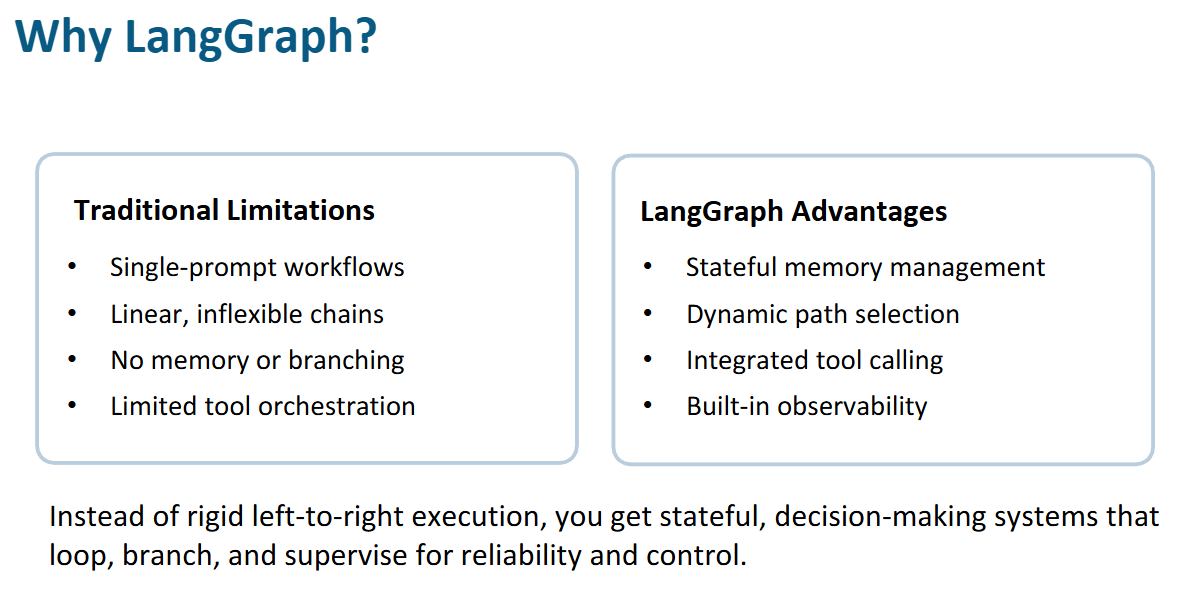

## Why LangGraph?

LangGraph addresses the core limitations of traditional LLM workflows by enabling **stateful, dynamic, and controllable execution systems** that better reflect real-world problem-solving.

---

### Traditional Limitations

Conventional approaches (e.g., simple chains or DAGs) impose strict constraints on how workflows are executed.

#### Single-Prompt Workflows

- Most systems rely on a **single LLM call**:
  
$$
\text{output} = f(\text{input})
$$

- No iteration or refinement
- Limited ability to correct mistakes

---

#### Linear, Inflexible Chains

- Execution follows a fixed sequence:

$$
A \rightarrow B \rightarrow C
$$

- No deviation from predefined paths
- Cannot adapt to intermediate results

---

#### No Memory or Branching

- Stateless systems do not retain context across steps:

$$
\text{state}_t \neq \text{state}_{t+1}
$$

- No ability to:
  - Accumulate knowledge
  - Make decisions based on history
  - Branch into alternative paths

---

#### Limited Tool Orchestration

- Tool usage is static and predefined
- No dynamic selection of tools based on context

---

### LangGraph Advantages

LangGraph introduces capabilities that transform workflows into **adaptive systems**.

---

#### Stateful Memory Management

- Shared state evolves across execution:

$$
\text{state}_{t+1} = f(\text{state}_t)
$$

- Enables:
  - Context retention
  - Iterative refinement
  - Cross-step reasoning

---

#### Dynamic Path Selection

- Execution paths are determined at runtime:

$$
\text{next\_node} =
\begin{cases}
A & \text{if condition}_1 \\
B & \text{if condition}_2
\end{cases}
$$

- Supports:
  - Conditional logic
  - Adaptive workflows
  - Intelligent routing

---

#### Integrated Tool Calling

- Tools are first-class components in the graph
- The system can decide:

$$
\text{tool} = \arg\max_{\text{available tools}} \; \text{relevance}
$$

- Enables:
  - API calls
  - Retrieval systems
  - External computations

---

#### Built-in Observability

- Every step in the graph is traceable
- State transitions can be monitored:

$$
(\text{state}_0 \rightarrow \text{state}_1 \rightarrow \dots \rightarrow \text{state}_n)
$$

- Improves:
  - Debugging
  - Reliability
  - Transparency

---

### From Pipelines to Systems

Traditional approach:

- Rigid, left-to-right execution
- No feedback or control loops

LangGraph approach:

- Stateful execution
- Decision-making at each step
- Support for loops and branching

---

### Conceptual Shift

Instead of:

$$
\text{Pipeline} = f(\text{input})
$$

You design:

$$
\text{System} = f(\text{state}, \text{conditions}, \text{history})
$$

---

### Key Takeaways

- Traditional chains are **static and limited**
- LangGraph enables **dynamic, stateful, and adaptive workflows**
- Supports **looping, branching, and tool integration**
- Provides the foundation for **reliable agentic systems**

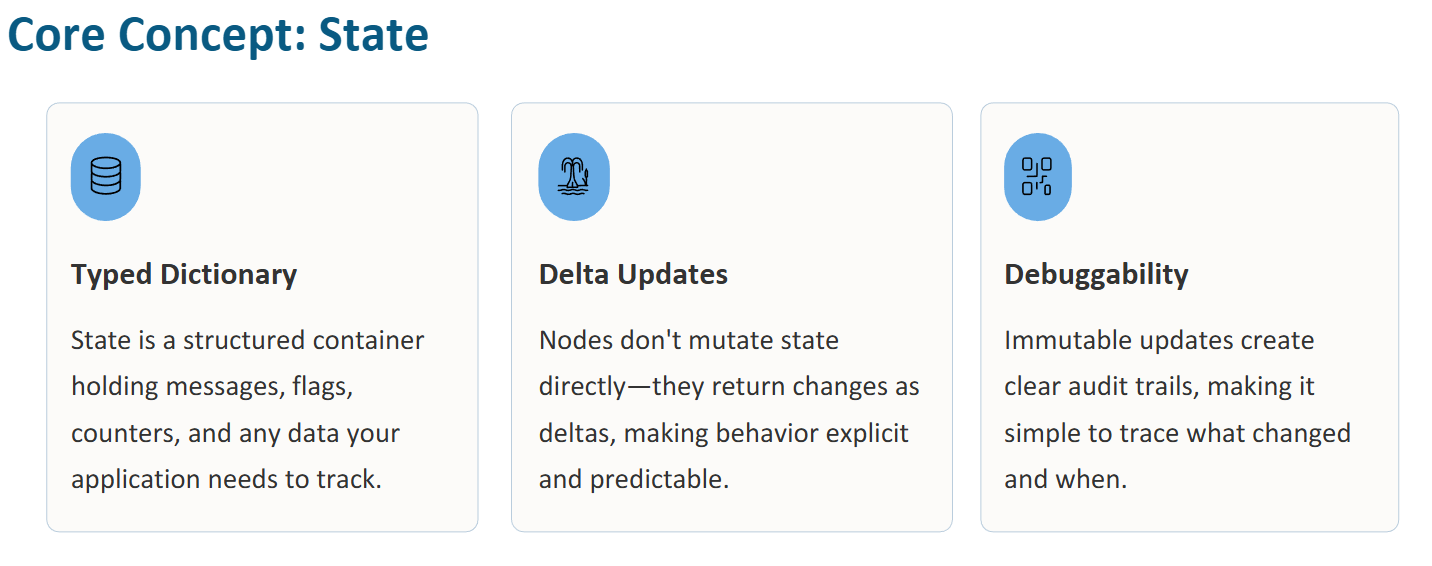

## Core Concept: State

In LangGraph, **state** is the central mechanism that enables **memory, coordination, and control** across the entire workflow. It acts as the shared source of truth that all nodes read from and write to.

---

### Formal Representation

State can be modeled as a structured object:

$$
\text{state} \in \mathcal{S}
$$

Where $\mathcal{S}$ is the space of all possible application states.

Each step updates the state as:

$$
\text{state}_{t+1} = \text{state}_t \oplus \Delta_t
$$

Where:
- $\Delta_t$ = incremental update (delta)
- $\oplus$ = merge operation

---

### Typed Dictionary

State is typically implemented as a **typed dictionary**:

- A structured container with predefined fields
- Ensures consistency and clarity across nodes

**Example:**

```python
from typing import TypedDict, List

class State(TypedDict):
    question: str
    documents: List[str]
    answer: str
    status: str
    iteration: int
````

**Characteristics:**

* Explicit schema definition
* Stronger guarantees about data structure
* Easier collaboration across components

---

### What State Stores

State can include any data required for execution:

* Messages (user input, LLM responses)
* Retrieved documents
* Flags (e.g., `"retry"`, `"approved"`)
* Counters (e.g., iteration count)
* Tool outputs
* Intermediate reasoning steps

---

### Delta Updates (Immutable Pattern)

Nodes **do not mutate state directly**. Instead, they return **delta updates**:

$$
\Delta_t = f(\text{state}_t)
$$

Then the system applies:

$$
\text{state}_{t+1} = \text{merge}(\text{state}_t, \Delta_t)
$$

**Example:**

```python
def evaluate_node(state):
    if len(state["documents"]) == 0:
        return {"status": "retry"}
    return {"status": "approved"}
```

**Key Benefits:**

* Predictable behavior
* No hidden side effects
* Easier reasoning about transitions

---

### Immutability and Debuggability

Because updates are applied as deltas:

* Each state transition is **explicit and traceable**
* The system forms a sequence:

$$
\text{state}_0 \rightarrow \text{state}_1 \rightarrow \dots \rightarrow \text{state}_n
$$

This enables:

* Full audit trails
* Time-travel debugging
* Inspection of intermediate steps

---

### State as Communication Layer

Nodes do not communicate directly with each other.

Instead, they interact **through state**:

$$
\text{Node}_i \rightarrow \text{State} \rightarrow \text{Node}_j
$$

This creates:

* Loose coupling between components
* Modular design
* Easier testing and replacement of nodes

---

### State Enables Agentic Behavior

State is what makes the system:

* **Iterative** → tracks progress across loops
* **Adaptive** → stores results for decision-making
* **Context-aware** → accumulates knowledge over time

Without state:

$$
\text{System} = f(\text{input})
$$

With state:

$$
\text{System} = f(\text{state}_t)
$$

---

### Key Takeaways

* State is the **core abstraction** in LangGraph
* Implemented as a **typed, structured dictionary**
* Updated via **delta-based, immutable transformations**
* Enables **traceability, modularity, and iteration**
* Acts as the backbone for **agentic workflows**



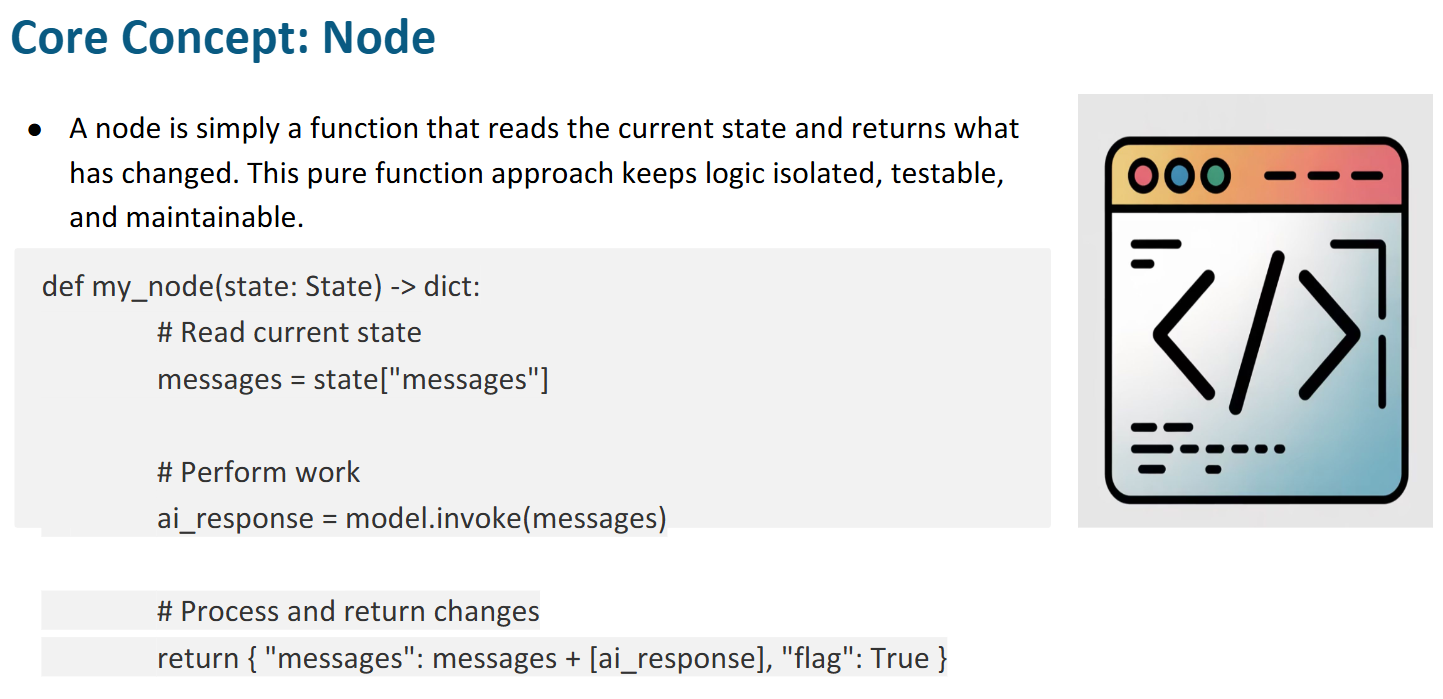

## Core Concept: Node

In LangGraph, a **node** is the fundamental unit of computation. It represents a **pure function** that:

- Reads the current state
- Performs some operation
- Returns a **delta update** describing what changed

---

### Formal Definition

A node can be defined as a function:

$$
f : \mathcal{S} \rightarrow \Delta
$$

Where:

- $\mathcal{S}$ = state space  
- $\Delta$ = partial update (delta)

The system then applies:

$$
\text{state}_{t+1} = \text{state}_t \oplus f(\text{state}_t)
$$

---

### Core Responsibilities

Each node performs three key steps:

1. **Read State**
2. **Execute Logic**
3. **Return Changes (Delta)**

---

### Example Node

```python
def my_node(state: State) -> dict:
    # Read current state
    messages = state["messages"]

    # Perform work
    ai_response = model.invoke(messages)

    # Return delta update
    return {
        "messages": messages + [ai_response],
        "flag": True
    }
````

---

### Pure Function Design

Nodes follow a **pure function paradigm**:

* No direct mutation of state
* No hidden side effects
* Output depends only on input state

Formally:

$$
f(\text{state}_t) = \Delta_t
$$

**Implications:**

* Deterministic behavior
* Easier testing and debugging
* Predictable state transitions

---

### Isolation and Modularity

Each node is **self-contained**:

* Encapsulates a single responsibility
* Can be developed and tested independently
* Can be reused across workflows

**Examples of node types:**

* Retrieval node (fetch documents)
* LLM node (generate responses)
* Evaluation node (score output)
* Tool node (call APIs or services)

---

### Node as a Transformation

Nodes transform state incrementally:

$$
(\text{input state}) \xrightarrow{\text{node}} (\text{delta}) \xrightarrow{\oplus} (\text{updated state})
$$

This creates a pipeline of transformations:

$$
\text{state}_0 \rightarrow \text{state}_1 \rightarrow \dots \rightarrow \text{state}_n
$$

---

### Composability

Nodes can be combined to form complex workflows:

* Sequential composition:

$$
f_1 \rightarrow f_2 \rightarrow f_3
$$

* Conditional routing:

$$
f_i \rightarrow
\begin{cases}
f_j & \text{if condition} \
f_k & \text{otherwise}
\end{cases}
$$

* Cyclical execution (loops):

$$
f_i \rightarrow f_j \rightarrow f_i
$$

---

### Node Types in Practice

Common patterns include:

* **Generator Node** → produces LLM outputs
* **Evaluator Node** → checks quality or correctness
* **Router Node** → decides next step
* **Tool Node** → interacts with external systems

---

### Why Nodes Matter

Nodes enable:

* Fine-grained control over execution
* Clear separation of concerns
* Flexible orchestration via graphs
* Scalable and maintainable system design

---

### Key Takeaways

* A node is a **pure function over state**
* It **reads state and returns a delta**
* Nodes are **modular, testable, and composable**
* They form the building blocks of **graph-based workflows**


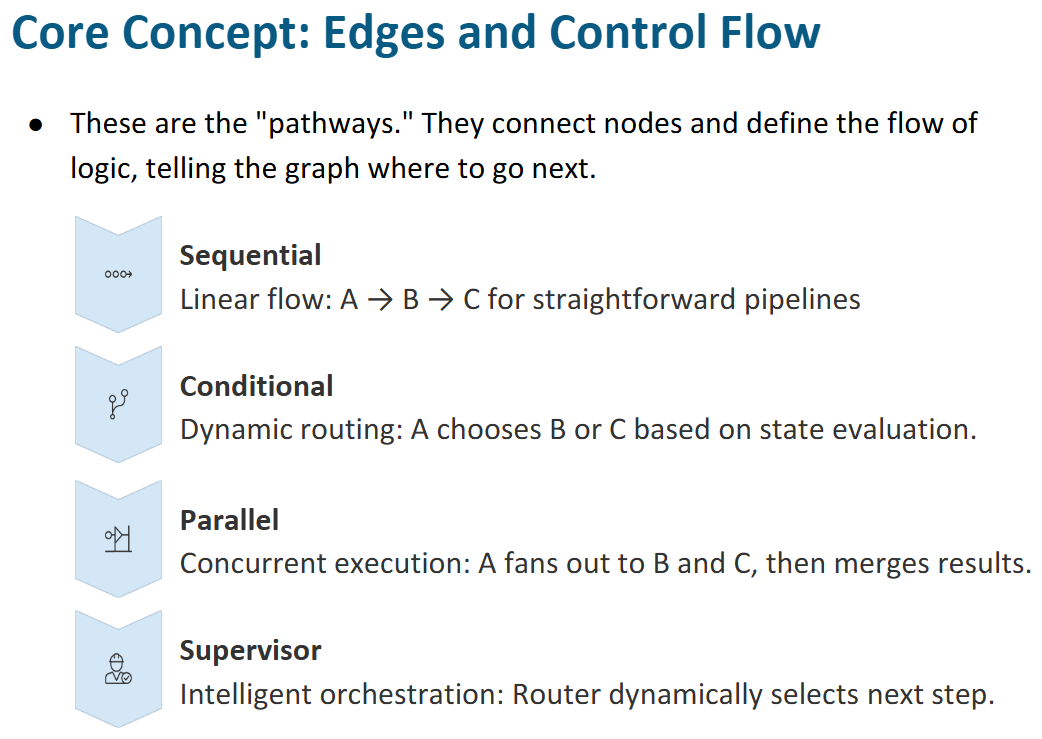

## Core Concept: Edges and Control Flow

In LangGraph, **edges** define how nodes are connected and determine the **control flow** of execution. They act as the **pathways** that guide how the system transitions from one computation step to another.

---

### Formal Definition

Edges can be represented as:

$$
E \subseteq V \times V
$$

Where:

- $V$ = set of nodes  
- $E$ = set of directed transitions between nodes  

Each edge defines a possible step in execution:

$$
\text{Node}_i \rightarrow \text{Node}_j
$$

---

### Role of Edges

Edges are responsible for:

- Defining execution order
- Enabling branching and decision-making
- Supporting iteration (cycles)
- Coordinating parallel execution

---

### Types of Control Flow

LangGraph supports multiple execution patterns through different types of edges.

---

### Sequential Flow

A simple, linear progression:

$$
A \rightarrow B \rightarrow C
$$

**Characteristics:**

- Deterministic execution
- Each node runs after the previous one completes
- Suitable for straightforward pipelines

---

### Conditional Flow

Dynamic routing based on state:

$$
\text{next\_node} =
\begin{cases}
B & \text{if condition(state)} \\
C & \text{otherwise}
\end{cases}
$$

**Characteristics:**

- Decision-making at runtime
- Enables adaptive workflows
- Core mechanism for agent behavior

---

### Parallel Flow

Concurrent execution of multiple nodes:

$$
A \rightarrow \{B, C\} \rightarrow D
$$

**Characteristics:**

- Fan-out: one node triggers multiple nodes
- Fan-in: results are merged later
- Improves performance and efficiency

---

### Supervisor (Router) Pattern

A specialized control mechanism where a node decides the next step:

$$
\text{router(state)} \rightarrow \text{next node}
$$

**Characteristics:**

- Centralized decision-making
- Dynamic orchestration of complex workflows
- Often implemented using an LLM or rule-based logic

---

### Control Flow as a Function of State

Execution in LangGraph is not fixed—it depends on the current state:

$$
\text{next\_node} = f(\text{state}_t)
$$

This enables:

- Context-aware transitions
- Adaptive behavior
- Iterative refinement

---

### Combining Flow Patterns

Real-world workflows combine multiple edge types:

- Sequential + Conditional → branching pipelines  
- Conditional + Cyclical → retry loops  
- Parallel + Merge → distributed processing  

Example:

```text
A → B → (C or D)
      ↓
     {E, F} → G
````

---

### Why Control Flow Matters

Edges transform a set of nodes into a **coherent system**:

* Define how logic is executed
* Enable flexibility and adaptability
* Allow systems to behave like agents rather than pipelines

---

### Key Takeaways

* Edges define **how nodes are connected and executed**
* Control flow can be **sequential, conditional, parallel, or dynamic**
* Execution depends on **state-driven decisions**
* Enables **complex, agentic workflows with loops and branching**




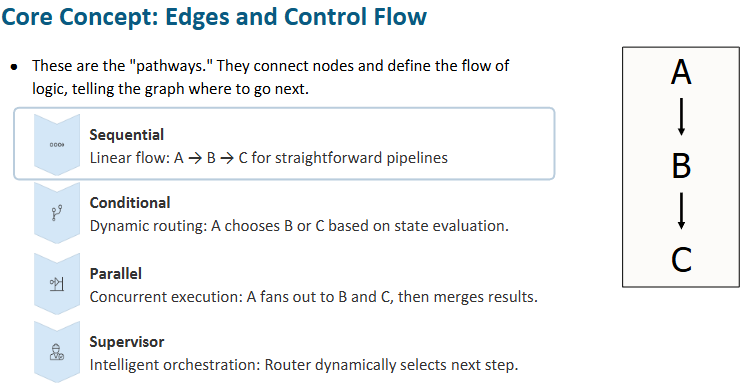

## Core Concept: Edges and Control Flow

**Edges** define the **pathways** between nodes and control how execution flows through the graph. They determine **what happens next**, transforming isolated nodes into a coordinated, intelligent system.

---

### Formal Definition

Edges are directed transitions:

$$
E \subseteq V \times V
$$

Each edge represents:

$$
\text{Node}_i \rightarrow \text{Node}_j
$$

Execution progresses by following these transitions, guided by the current state.

---

### Sequential Flow

A **linear execution path** where each step follows the previous one:

$$
A \rightarrow B \rightarrow C
$$

**Characteristics:**

- Fixed and predictable order
- No branching or deviation
- Suitable for simple pipelines

**Use Case:**
- Basic RAG: Retrieve → Generate → Output

---

### Conditional Flow

A **dynamic branching mechanism** where the next node depends on state evaluation:

$$
\text{next\_node} =
\begin{cases}
B & \text{if condition(state)} \\
C & \text{otherwise}
\end{cases}
$$

**Characteristics:**

- Runtime decision-making
- Enables adaptive behavior
- Core for implementing agents

**Use Case:**
- Retry if retrieval fails, otherwise proceed to generation

---

### Parallel Flow

A **fan-out/fan-in pattern** where multiple nodes execute concurrently:

$$
A \rightarrow \{B, C\} \rightarrow D
$$

**Characteristics:**

- Improves efficiency via concurrency
- Independent tasks run simultaneously
- Results are merged later

**Use Case:**
- Query multiple data sources in parallel, then aggregate results

---

### Supervisor (Router) Pattern

A **central decision-making node** that determines the next step:

$$
\text{next\_node} = f(\text{state}_t)
$$

**Characteristics:**

- Intelligent orchestration
- Can be rule-based or LLM-driven
- Dynamically selects tools or actions

**Use Case:**
- Decide whether to call a tool, ask a follow-up question, or generate an answer

---

### Control Flow as State-Driven Execution

Unlike static pipelines, execution depends on state:

$$
\text{Node}_i \xrightarrow{\text{state}_t} \text{Node}_j
$$

This means:

- The same node can lead to different paths
- Behavior evolves as state changes
- Enables loops and iterative refinement

---

### Combining Patterns

Real workflows combine multiple edge types:

```text
A → B → (C or D)
      ↓
     {E, F} → G
````

This supports:

* Branching decisions
* Parallel execution
* Multi-step reasoning

---

### Why Edges Matter

Edges are what make the system:

* **Dynamic** → not fixed to one path
* **Adaptive** → reacts to intermediate results
* **Composable** → combines simple nodes into complex systems

---

### Key Takeaways

* Edges define **how nodes connect and execute**
* Control flow can be **sequential, conditional, parallel, or dynamic**
* Execution is **state-dependent**, not predefined
* Enables **agentic behavior through flexible orchestration**



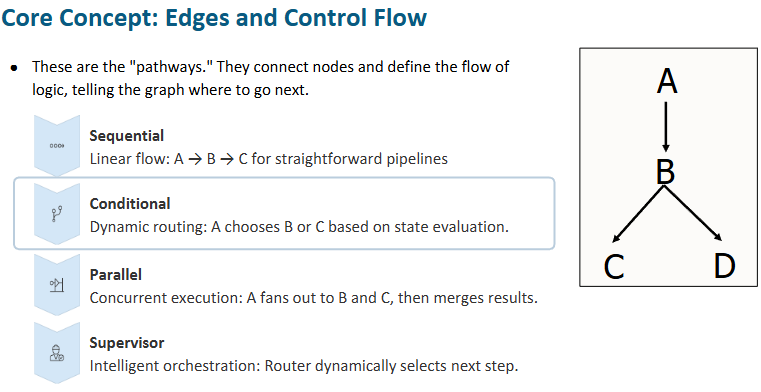

## Core Concept: Edges and Control Flow (Conditional)

**Conditional edges** enable **dynamic routing**, allowing the system to choose the next node based on the current state. This is a key mechanism for building **adaptive and intelligent workflows**.

---

### Formal Definition

A conditional edge defines a transition function:

$$
\text{next\_node} = f(\text{state}_t)
$$

Where:

- $\text{state}_t$ = current state  
- $f$ = decision function mapping state to the next node  

---

### Conditional Branching

Instead of a fixed path, execution branches:

$$
A \rightarrow
\begin{cases}
B & \text{if condition}_1(\text{state}) \\
C & \text{if condition}_2(\text{state})
\end{cases}
$$

This allows:

- Multiple possible execution paths
- Decisions based on intermediate results
- Runtime adaptability

---

### Example Flow

```text
A → B
     ↙   ↘
    C     D
````

* Node $B$ evaluates the state
* Based on the result:

  * Route to $C$
  * Or route to $D$

---

### Implementation Pattern

In practice, conditional routing is implemented using a function:

```python
workflow.add_conditional_edges(
    "evaluate_node",
    lambda state: state["status"],
    {
        "approved": "generate_node",
        "retry": "rewrite_query_node",
        "END": END
    }
)
```

---

### Decision Functions

The routing function can be:

* Rule-based:

$$
f(\text{state}) =
\begin{cases}
\text{"retry"} & \text{if score} < 0.7 \
\text{"approved"} & \text{otherwise}
\end{cases}
$$

* LLM-based:

  * Model decides next step based on reasoning

---

### Why Conditional Flow Matters

Conditional edges enable:

* **Adaptive behavior** → system reacts to results
* **Error handling** → retry or fallback paths
* **Decision-making** → choose best next action
* **Agent-like reasoning** → evaluate before acting

---

### Conditional Flow vs Sequential Flow

| Feature         | Sequential ($A \rightarrow B \rightarrow C$) | Conditional |
| --------------- | -------------------------------------------- | ----------- |
| Execution path  | Fixed                                        | Dynamic     |
| Decision-making | None                                         | State-based |
| Flexibility     | Low                                          | High        |
| Adaptability    | None                                         | Strong      |

---

### Conditional + Cycles

Conditional edges often enable loops:

$$
B \rightarrow
\begin{cases}
C & \text{if done} \
B & \text{if retry}
\end{cases}
$$

This creates:

* Iterative refinement
* Self-correcting systems
* Feedback-driven workflows

---

### Key Takeaways

* Conditional edges enable **dynamic routing based on state**
* Execution paths are **not fixed מראש**
* Critical for **decision-making and adaptability**
* Foundation for **agentic and iterative systems**



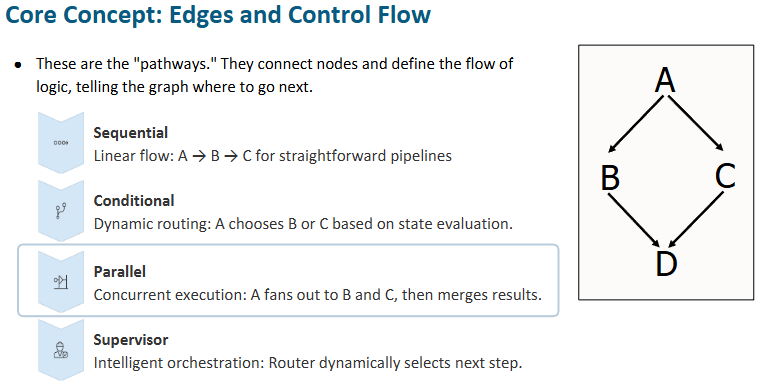

## Core Concept: Edges and Control Flow (Parallel)

**Parallel edges** enable **concurrent execution**, allowing a node to trigger multiple downstream nodes simultaneously and later combine their results. This pattern is essential for improving performance and handling independent tasks efficiently.

---

### Formal Definition

Parallel execution can be represented as:

$$
A \rightarrow \{B, C\} \rightarrow D
$$

Where:

- Node $A$ **fans out** into multiple nodes ($B$, $C$)
- Nodes $B$ and $C$ execute **independently and concurrently**
- Results are **merged** at node $D$

---

### Fan-Out / Fan-In Pattern

Parallel flow consists of two phases:

#### Fan-Out

$$
A \rightarrow B,\; A \rightarrow C
$$

- A single node triggers multiple branches
- Each branch operates on the same or derived state

#### Fan-In

$$
\{B, C\} \rightarrow D
$$

- Outputs from parallel nodes are combined
- Downstream node aggregates results

---

### Example Flow

```text
      A
     / \
    B   C
     \ /
      D
````

* $B$ and $C$ run at the same time
* $D$ waits for both to complete

---

### State Behavior in Parallel Execution

Each parallel node receives the **same base state**:

$$
\text{state}_t \rightarrow
\begin{cases}
f_B(\text{state}_t) \
f_C(\text{state}_t)
\end{cases}
$$

Each produces its own delta:

$$
\Delta_B,; \Delta_C
$$

These are merged into a unified state:

$$
\text{state}_{t+1} = \text{state}_t \oplus \Delta_B \oplus \Delta_C
$$

---

### Use Cases

Parallel edges are useful when tasks are:

* Independent of each other
* Computation-heavy or time-consuming
* Beneficial to execute simultaneously

**Examples:**

* Query multiple retrieval sources at once
* Run different evaluation metrics in parallel
* Call multiple APIs and aggregate responses

---

### Benefits

* **Performance** → reduces total execution time
* **Scalability** → distributes workload across components
* **Modularity** → independent branches can evolve separately

---

### Challenges

* **State merging conflicts**:

$$
\Delta_B \cap \Delta_C \neq \emptyset
$$

* Requires careful design to avoid overwriting data

* **Synchronization**:

  * Downstream nodes must wait for all branches to complete

---

### Parallel vs Sequential

| Feature      | Sequential ($A \rightarrow B \rightarrow C$) | Parallel ($A \rightarrow {B,C}$) |
| ------------ | -------------------------------------------- | -------------------------------- |
| Execution    | One step at a time                           | Concurrent                       |
| Speed        | Slower                                       | Faster (when independent)        |
| Complexity   | Low                                          | Higher                           |
| Coordination | Minimal                                      | Requires merging                 |

---

### Key Takeaways

* Parallel edges enable **concurrent execution of nodes**
* Follow a **fan-out / fan-in pattern**
* Improve **performance and efficiency**
* Require careful **state merging and synchronization**
* Essential for scaling complex agent workflows



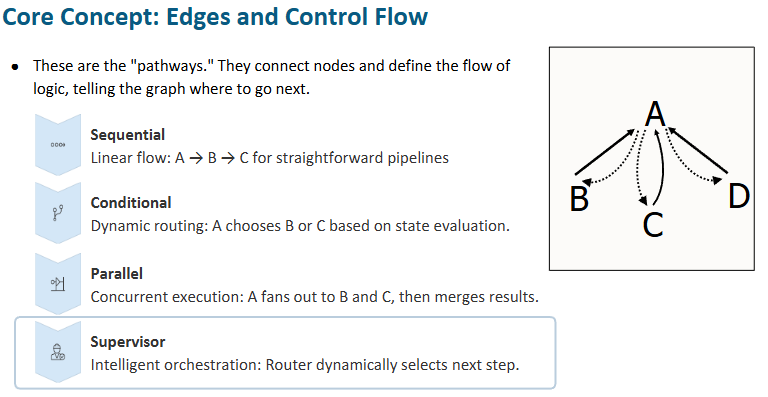

## Core Concept: Edges and Control Flow (Supervisor)

The **Supervisor (Router) pattern** introduces a centralized decision-making mechanism that dynamically controls the flow of execution. Instead of fixed or simple conditional paths, a **supervisor node intelligently selects the next step** based on the current state.

---

### Formal Definition

A supervisor is a routing function:

$$
\text{next\_node} = f_{\text{router}}(\text{state}_t)
$$

Where:

- $\text{state}_t$ = current system state  
- $f_{\text{router}}$ = decision function (rule-based or LLM-based)  

---

### Conceptual Flow

```text
        A (Supervisor)
      ↙   ↓    ↘
     B    C     D
      ↖   ↑    ↗
        (feedback)
````

* Node $A$ acts as the **controller**
* It selects which node ($B$, $C$, or $D$) to execute next
* Results from those nodes can return to $A$ for further decisions

---

### Supervisor as a Control Loop

The supervisor often participates in a loop:

$$
A \rightarrow X \rightarrow A
$$

This creates an iterative system:

$$
\text{state}*{t+1} = f_X(\text{state}*t)
\quad \Rightarrow \quad
\text{next_node} = f*{\text{router}}(\text{state}*{t+1})
$$

---

### Implementation Pattern

```python
workflow.add_conditional_edges(
    "supervisor_node",
    lambda state: state["next_step"],
    {
        "tool": "tool_node",
        "analyze": "analysis_node",
        "respond": "response_node",
        "END": END
    }
)
```

---

### Types of Supervisors

#### Rule-Based Supervisor

Uses explicit conditions:

$$
f_{\text{router}}(\text{state}) =
\begin{cases}
\text{"tool"} & \text{if missing data} \
\text{"respond"} & \text{if answer ready}
\end{cases}
$$

---

#### LLM-Based Supervisor

Uses a model to decide:

* Interprets context
* Chooses next action
* Enables reasoning-driven orchestration

---

### Responsibilities of a Supervisor

* Decide the next node to execute
* Coordinate multiple tools or agents
* Handle retries and fallback strategies
* Manage termination conditions

---

### Why Supervisor Pattern Matters

The supervisor enables:

* **Centralized control** → one node governs execution
* **Dynamic orchestration** → adapts to changing state
* **Iterative reasoning** → loops until goal is achieved
* **Agent-like behavior** → plan, act, observe, repeat

---

### Supervisor vs Conditional Flow

| Feature           | Conditional Edge      | Supervisor Pattern       |
| ----------------- | --------------------- | ------------------------ |
| Decision scope    | Local (single branch) | Global (entire workflow) |
| Complexity        | Simple                | High                     |
| Control structure | Static mapping        | Dynamic orchestration    |
| Iteration         | Limited               | Core feature             |

---

### Supervisor in Agentic Systems

The supervisor is often the **"brain" of the agent**:

* Decides when to:

  * Call tools
  * Retrieve data
  * Generate responses
  * Ask for clarification
* Continuously evaluates progress

---

### Key Takeaways

* Supervisor is a **central routing node** that controls execution
* Uses **state-driven decision-making**
* Enables **loops, planning, and coordination**
* Critical for building **complex, agentic workflows**



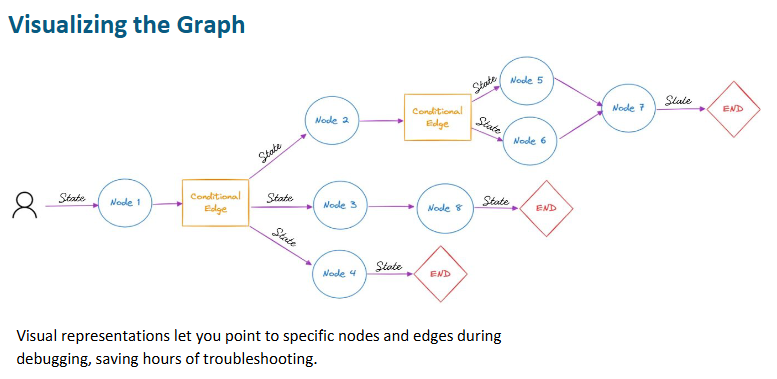

## Visualizing the Graph

Visualizing a LangGraph workflow provides a **clear, structural view** of how nodes, edges, and state transitions interact. It transforms abstract execution logic into an **intuitive, inspectable diagram**.

---

### Graph Representation

A workflow can be represented as a directed graph:

$$
G = (V, E, S)
$$

Where:

- $V$ = nodes (processing steps)  
- $E$ = edges (control flow transitions)  
- $S$ = state propagated through the graph  

---

### Execution Flow Overview

A typical graph visualization shows:

- Entry point (user input)
- Sequential and conditional transitions
- Parallel branches
- Termination points

Example structure:

```text
User → Node 1 → (Conditional)
                  ↙       ↓        ↘
              Node 2   Node 3   Node 4
                ↓         ↓        ↓
         (Conditional)  Node 8     END
            ↙     ↘
        Node 5   Node 6
             \   /
              Node 7 → END
````

---

### State Propagation

State flows through every edge:

$$
\text{state}_0 \rightarrow \text{Node}_1 \rightarrow \text{state}_1 \rightarrow \dots \rightarrow \text{state}_n
$$

Each node:

$$
\text{state}_{t+1} = \text{state}_t \oplus \Delta_t
$$

Visualization makes it easier to track:

* Where state is modified
* How data evolves
* Which nodes contribute to final output

---

### Conditional and Parallel Paths

Graph diagrams clearly expose:

#### Conditional Branching

$$
\text{Node}_i \rightarrow
\begin{cases}
\text{Node}_j \
\text{Node}_k
\end{cases}
$$

#### Parallel Execution

$$
\text{Node}_i \rightarrow {\text{Node}_j, \text{Node}_k}
$$

This helps identify:

* Decision points
* Concurrent operations
* Merge points

---

### Debugging and Observability

Visualization enables:

* Step-by-step tracing of execution paths
* Identification of bottlenecks or failures
* Inspection of intermediate states

You can follow:

$$
\text{execution path} = (v_1, v_2, \dots, v_n)
$$

And analyze:

* Which path was taken
* Why a branch was selected
* Where errors occurred

---

### Benefits of Visualization

* **Clarity** → understand complex workflows at a glance
* **Debugging** → pinpoint issues quickly
* **Communication** → explain system behavior to others
* **Optimization** → identify inefficiencies or redundancies

---

### Visualization as a Development Tool

Graph visualization is not just for display—it supports:

* Designing workflows before implementation
* Validating logic and edge cases
* Monitoring runtime execution

---

### Key Takeaways

* Graph visualization makes execution **transparent and traceable**
* Helps understand **state transitions and control flow**
* Essential for **debugging, optimization, and system design**
* Bridges the gap between **conceptual design and implementation**



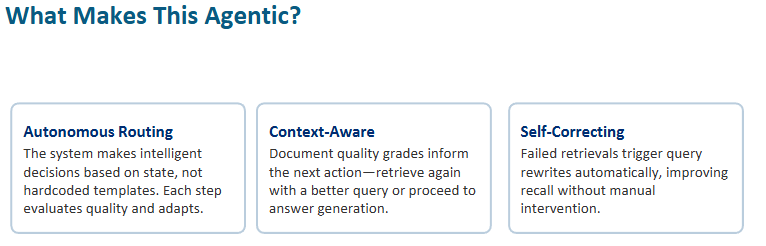

## What Makes This Agentic?

Agentic systems go beyond static pipelines by introducing **autonomy, adaptability, and iterative improvement**. These capabilities emerge from the combination of **state, control flow, and decision-making**.

---

### Autonomous Routing

The system makes decisions dynamically based on state:

$$
\text{next\_node} = f(\text{state}_t)
$$

Instead of following hardcoded paths:

$$
A \rightarrow B \rightarrow C
$$

The system evaluates:

- Current progress  
- Quality of intermediate outputs  
- Available actions  

**Result:**

- Flexible execution paths  
- Real-time adaptation  
- Reduced reliance on predefined logic  

---

### Context-Aware Decision Making

Each step uses accumulated context to guide behavior:

$$
\text{decision}_t = f(\text{state}_t, \text{history})
$$

Where:

- $\text{state}_t$ includes prior results  
- $\text{history}$ captures previous steps and outcomes  

**Example:**

- If retrieved documents are weak → refine query  
- If context is sufficient → proceed to generation  

**Impact:**

- Better reasoning  
- Improved relevance  
- More informed actions  

---

### Self-Correcting Behavior

Agentic systems incorporate feedback loops:

$$
\text{state}_{t+1} = f(\text{state}_t)
\quad \text{until} \quad \text{condition} = \text{True}
$$

This enables:

- Automatic retries  
- Query rewriting  
- Iterative refinement  

**Example Loop:**

$$
\text{Retrieve} \rightarrow \text{Evaluate} \rightarrow
\begin{cases}
\text{Retry} \\
\text{Generate}
\end{cases}
$$

---

### Emergent Agent Behavior

Combining these properties results in:

- **Planning** → deciding next steps  
- **Acting** → executing nodes/tools  
- **Observing** → evaluating outcomes  
- **Refining** → improving results iteratively  

This can be summarized as:

$$
\text{Agent} = (\text{State}, \text{Policy}, \text{Feedback Loop})
$$

---

### From Static to Agentic Systems

| Capability            | Traditional Pipelines | Agentic Systems |
|----------------------|----------------------|-----------------|
| Routing              | Fixed                | Dynamic         |
| Context Usage        | Limited              | Accumulated     |
| Error Handling       | Manual               | Automatic       |
| Iteration            | None                 | Built-in        |
| Adaptability         | Low                  | High            |

---

### Why This Matters

Agentic behavior enables systems to:

- Handle ambiguity and uncertainty  
- Improve results without manual intervention  
- Adapt to varying inputs and conditions  
- Operate more like **intelligent problem-solvers**

---

### Key Takeaways

- Agentic systems are **autonomous, context-aware, and self-correcting**
- Decisions are driven by **state and feedback loops**
- Behavior emerges from **iteration and dynamic control flow**
- This is the foundation for **advanced AI agents and Agentic RAG systems**

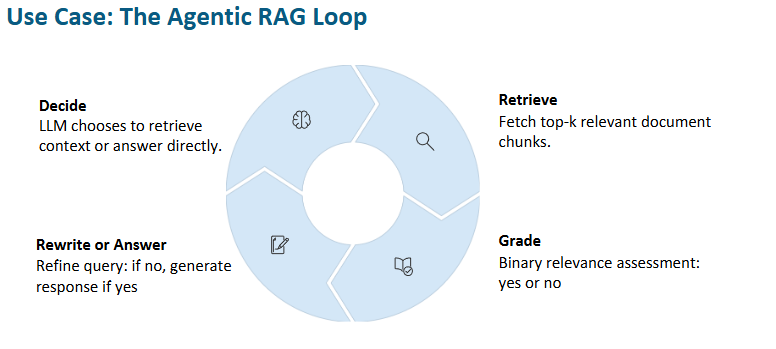

## Use Case: The Agentic RAG Loop

The **Agentic RAG Loop** is a dynamic, iterative workflow that enhances traditional Retrieval-Augmented Generation by incorporating **decision-making, evaluation, and refinement** at each step.

---

### High-Level Loop

The process can be modeled as a cyclical system:

$$
\text{Decide} \rightarrow \text{Retrieve} \rightarrow \text{Grade} \rightarrow \text{Rewrite/Answer} \rightarrow \text{Decide}
$$

This loop continues until a **termination condition** is satisfied.

---

### Step 1: Decide

The system determines whether to:

- Retrieve additional context  
- Or generate an answer directly  

Formally:

$$
\text{action} =
\begin{cases}
\text{retrieve} & \text{if insufficient context} \\
\text{answer} & \text{if confident}
\end{cases}
$$

**Key Role:**

- Acts as a **router (supervisor)**
- Evaluates readiness to answer

---

### Step 2: Retrieve

Fetch relevant information from a knowledge source:

$$
\text{docs} = \text{Retriever}(\text{query}, k)
$$

Where:

- $k$ = number of top documents retrieved  

**Purpose:**

- Ground the response in external knowledge  
- Reduce hallucinations  

---

### Step 3: Grade

Evaluate the quality and relevance of retrieved documents:

$$
\text{score} =
\begin{cases}
1 & \text{if relevant} \\
0 & \text{if not relevant}
\end{cases}
$$

**Key Role:**

- Filters useful vs irrelevant context  
- Determines whether refinement is needed  

---

### Step 4: Rewrite or Answer

Based on grading:

$$
\text{next step} =
\begin{cases}
\text{rewrite query} & \text{if score} = 0 \\
\text{generate answer} & \text{if score} = 1
\end{cases}
$$

#### Rewrite Path

- Improve query formulation  
- Increase retrieval quality  

#### Answer Path

- Generate final response using validated context  

---

### Iterative Refinement Loop

The system repeats:

$$
\text{query}_{t+1} = f(\text{query}_t, \text{feedback})
$$

Until:

$$
\text{quality threshold met} = \text{True}
$$

---

### Why This Is Powerful

The Agentic RAG loop enables:

- **Self-correction** → retries when retrieval fails  
- **Adaptive retrieval** → improves queries dynamically  
- **Quality control** → evaluates before answering  
- **Efficient execution** → avoids unnecessary retrieval  

---

### Comparison with Traditional RAG

| Feature              | Traditional RAG              | Agentic RAG Loop           |
|---------------------|-----------------------------|----------------------------|
| Retrieval           | One-shot                    | Iterative                  |
| Evaluation          | None                        | Built-in grading           |
| Query refinement    | Manual                      | Automatic                  |
| Control flow        | Linear                      | Cyclical                   |
| Adaptability        | Low                         | High                       |

---

### Execution as a State Machine

The loop can be viewed as a state transition system:

$$
\text{state}_{t+1} = f(\text{state}_t, \text{action}_t)
$$

Where actions include:

- Retrieve  
- Grade  
- Rewrite  
- Answer  

---

### Key Takeaways

- Agentic RAG introduces a **feedback loop into retrieval workflows**
- Combines **decision-making, evaluation, and generation**
- Enables **iterative improvement and higher-quality outputs**
- Represents a shift from **static pipelines to adaptive systems**

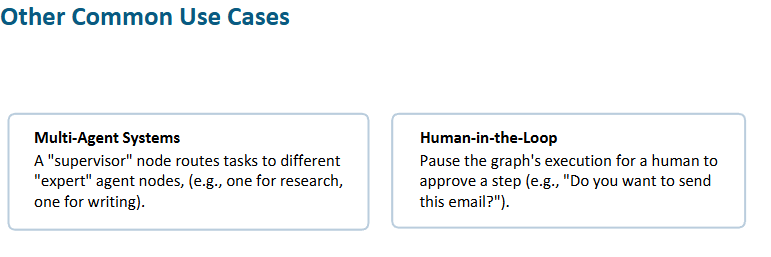

## Other Common Use Cases

LangGraph enables a variety of advanced application patterns beyond Agentic RAG, particularly in scenarios requiring **coordination, specialization, and human oversight**.

---

### Multi-Agent Systems

Multi-agent systems distribute tasks across specialized components, coordinated by a central **supervisor node**.

---

#### Architecture

A supervisor routes tasks to expert agents:

$$
\text{agent} = f_{\text{router}}(\text{state})
$$

Execution pattern:

$$
\text{Supervisor} \rightarrow \{\text{Agent}_1, \text{Agent}_2, \dots\}
$$

Each agent is responsible for a specific capability.

---

#### Example Roles

- **Research Agent** → retrieves and summarizes information  
- **Analysis Agent** → processes and interprets data  
- **Writing Agent** → generates structured output  

---

#### Workflow Example

```text
User → Supervisor
         ↓
   (Select Agent)
     ↙       ↘
Research   Writing
     ↓         ↓
     →→→ Merge Results → Output
````

---

#### Benefits

* **Specialization** → each agent optimized for a task
* **Scalability** → new agents can be added easily
* **Modularity** → components can evolve independently

---

### Human-in-the-Loop (HITL)

Human-in-the-loop workflows introduce **manual checkpoints** into automated systems, enabling validation, correction, or approval.

---

#### Control Mechanism

Execution pauses based on a condition:

$$
\text{continue} =
\begin{cases}
\text{True} & \text{if approved} \
\text{False} & \text{if rejected}
\end{cases}
$$

---

#### Example Flow

```text
A → B → (Human Approval)
           ↓
     Approved → C → Output
     Rejected → Modify → B
```

---

#### Use Cases

* Email or message approval
* Content moderation
* High-risk decision validation
* Compliance workflows

---

#### Benefits

* **Safety** → prevents unintended actions
* **Control** → human oversight in critical steps
* **Flexibility** → allows intervention and correction

---

### Combining Both Patterns

LangGraph allows combining multi-agent systems with HITL:

$$
\text{Supervisor} \rightarrow \text{Agent} \rightarrow \text{Human} \rightarrow \text{Next Step}
$$

This enables:

* Expert-driven automation
* Human validation loops
* Robust and trustworthy systems

---

### Key Takeaways

* Multi-agent systems enable **task specialization and coordination**
* Human-in-the-loop introduces **control and safety mechanisms**
* Both patterns enhance **reliability, flexibility, and scalability**
* LangGraph provides the structure to integrate them seamlessly



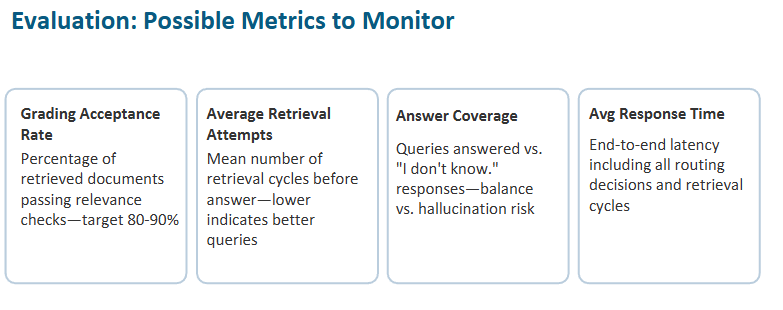

## Evaluation: Possible Metrics to Monitor

Evaluating an Agentic RAG system requires tracking metrics that reflect **retrieval quality, system efficiency, answer reliability, and overall performance**.

---

### Grading Acceptance Rate

Measures the proportion of retrieved documents that pass relevance checks:

$$
\text{Acceptance Rate} = \frac{\text{relevant documents}}{\text{retrieved documents}}
$$

**Target Range:**  
$$
80\% \text{ to } 90\%
$$

**Interpretation:**

- High → retrieval is effective  
- Low → poor query formulation or weak retriever  

**Why it matters:**

- Directly impacts answer quality  
- Reduces noise in downstream generation  

---

### Average Retrieval Attempts

Tracks how many retrieval cycles occur before producing a final answer:

$$
\text{Avg Attempts} = \frac{\sum \text{retrieval cycles}}{\text{queries}}
$$

**Interpretation:**

- Lower → efficient retrieval and good query design  
- Higher → excessive retries, possible inefficiencies  

**Trade-off:**

- Too low → may sacrifice quality  
- Too high → increases latency and cost  

---

### Answer Coverage

Measures how often the system provides a valid answer vs. fallback responses:

$$
\text{Coverage} = \frac{\text{answered queries}}{\text{total queries}}
$$

Where:

- “Answered” excludes responses like *"I don't know"*

**Consideration:**

- High coverage may increase hallucination risk  
- Balanced coverage ensures reliability and honesty  

---

### Average Response Time

Captures end-to-end latency:

$$
\text{Latency} = t_{\text{final}} - t_{\text{start}}
$$

Includes:

- Retrieval cycles  
- Routing decisions  
- LLM inference time  

**Interpretation:**

- Lower → faster user experience  
- Higher → may indicate inefficiencies in loops or parallel steps  

---

### Multi-Metric Trade-offs

These metrics are interdependent:

- Increasing retrieval attempts may improve:
  - Acceptance rate  
  - Answer quality  

But may worsen:

- Response time  
- System cost  

---

### Monitoring as a System Function

Evaluation can be viewed as:

$$
\text{Performance} = f(\text{quality}, \text{efficiency}, \text{coverage}, \text{latency})
$$

Where:

- Quality → Acceptance Rate  
- Efficiency → Avg Retrieval Attempts  
- Coverage → Answer Coverage  
- Latency → Response Time  

---

### Key Takeaways

- Evaluation requires **balancing multiple competing metrics**
- Retrieval quality and answer reliability are tightly coupled  
- Efficiency impacts both **cost and user experience**  
- Continuous monitoring is essential for **optimizing agentic systems**

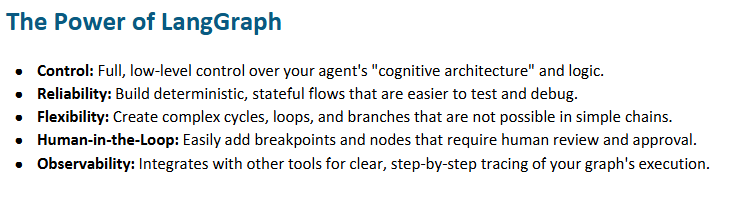

## The Power of LangGraph

LangGraph provides a powerful foundation for building **agentic systems** by enabling fine-grained control, adaptability, and transparency across complex workflows.

---

### Control

LangGraph offers **full, low-level control** over system behavior:

$$
\text{System Behavior} = f(\text{state}, \text{nodes}, \text{edges})
$$

This allows you to:

- Define custom control flow  
- Design precise execution logic  
- Shape the "cognitive architecture" of your agent  

**Impact:**

- No hidden abstractions  
- Maximum flexibility in system design  

---

### Reliability

Deterministic, stateful execution improves system reliability:

$$
\text{state}_{t+1} = \text{state}_t \oplus \Delta_t
$$

**Benefits:**

- Predictable behavior  
- Easier debugging and testing  
- Consistent outputs across runs  

---

### Flexibility

LangGraph supports complex execution patterns:

- Cycles (loops)
- Branching (conditional paths)
- Parallel execution

Formally:

$$
\text{next\_node} = f(\text{state}_t)
$$

**Result:**

- Workflows adapt dynamically  
- Enables advanced agent behaviors  
- Goes beyond linear chains  

---

### Human-in-the-Loop

Supports integration of human decision points:

$$
\text{continue} =
\begin{cases}
\text{True} & \text{if approved} \\
\text{False} & \text{otherwise}
\end{cases}
$$

**Capabilities:**

- Insert approval steps  
- Add manual overrides  
- Pause and resume execution  

---

### Observability

LangGraph enables detailed tracing of execution:

$$
(\text{state}_0 \rightarrow \text{state}_1 \rightarrow \dots \rightarrow \text{state}_n)
$$

**Benefits:**

- Step-by-step visibility  
- Easier debugging  
- Performance monitoring  

---

### Unified System Perspective

LangGraph allows you to think of your application as a system:

$$
\text{Agent System} =
(\text{State}, \text{Control Flow}, \text{Decision Logic})
$$

Instead of:

$$
\text{Pipeline} = f(\text{input})
$$

---

### Key Takeaways

- Provides **fine-grained control** over agent behavior  
- Enables **reliable, stateful execution**  
- Supports **flexible, dynamic workflows**  
- Integrates **human oversight seamlessly**  
- Offers **full observability for debugging and optimization**

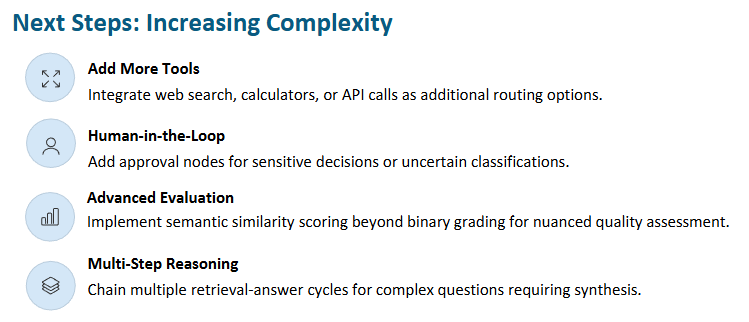

## Next Steps: Increasing Complexity

As you mature your LangGraph-based systems, you can progressively introduce more advanced capabilities to improve **performance, reliability, and intelligence**.

---

### Add More Tools

Expand the system’s capabilities by integrating external tools:

$$
\text{action} = \arg\max_{\text{tools}} \; \text{relevance}(\text{state})
$$

**Examples:**

- Web search APIs  
- Calculators  
- Databases  
- External services  

**Impact:**

- Enhances problem-solving ability  
- Enables real-world interactions  
- Supports tool-augmented reasoning  

---

### Human-in-the-Loop

Introduce approval checkpoints for sensitive or uncertain decisions:

$$
\text{continue} =
\begin{cases}
\text{True} & \text{if approved} \\
\text{False} & \text{otherwise}
\end{cases}
$$

**Use Cases:**

- High-risk actions  
- Low-confidence outputs  
- Compliance workflows  

**Impact:**

- Improves safety and trust  
- Enables human oversight  
- Reduces critical errors  

---

### Advanced Evaluation

Move beyond binary grading to more nuanced scoring:

$$
\text{score} = \text{similarity}(\text{retrieved}, \text{expected})
$$

**Techniques:**

- Semantic similarity (embeddings)  
- LLM-based evaluators  
- Multi-metric scoring systems  

**Impact:**

- Better quality assessment  
- More informed decision-making  
- Reduced false positives/negatives  

---

### Multi-Step Reasoning

Chain multiple reasoning and retrieval cycles:

$$
\text{state}_{t+1} = f(\text{state}_t)
\quad \text{for } t = 0, 1, \dots, n
$$

**Characteristics:**

- Iterative refinement  
- Decomposition of complex problems  
- Synthesis across multiple steps  

**Example:**

```text
Query → Retrieve → Analyze → Retrieve → Synthesize → Answer
````

**Impact:**

* Handles complex, multi-hop questions
* Improves depth and accuracy
* Enables advanced reasoning workflows

---

### Increasing System Complexity

As features are added:

$$
\text{System Capability} \propto \text{Tools} + \text{Evaluation} + \text{Control Flow} + \text{Memory}
$$

However:

* Complexity also increases system cost and latency
* Requires careful design and monitoring

---

### Key Takeaways

* Add tools to expand **capabilities**
* Introduce human oversight for **safety and control**
* Improve evaluation for **better quality decisions**
* Use multi-step reasoning for **complex problem-solving**
* Balance **capability vs. complexity** for optimal system design

